<function matplotlib.pyplot.show(close=None, block=None)>

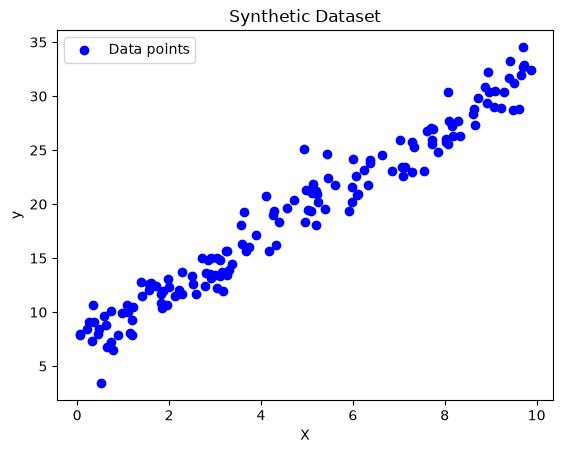

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# synthetic dataset 
X = np.random.uniform(0,10,150)
true_slope = 2.5
true_intercept = 7
noise = np.random.normal(0, 1.5,150)
y = true_slope * X + true_intercept + noise
y = y.reshape(-1, 1)

X = X.reshape(-1, 1)

plt.scatter(X, y, color='blue', label='Data points')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Dataset')
plt.legend()
plt.show

In [2]:
# initilizing w and b
w = 0
b = 0

In [3]:
# prediction functions
def predict(X, w, b):
    y_pred = w * X + b
    return y_pred


$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

In [4]:
def loss_function(y_true, y_pred):
    return np.sum((y_true - y_pred) ** 2)/len(y_true)

In [5]:
n = len(X)
y_pred = w * X + b        # current predictions
error = y_pred - y        # (ŷ - y) for every point

dw = (2/n) * np.sum(error * X)   # ∂J/∂w
db = (2/n) * np.sum(error)       # ∂J/∂b

In [6]:
print("Gradient w.r.t w:", dw)
print("Gradient w.r.t b:", db)

Gradient w.r.t w: -222.81053694052827
Gradient w.r.t b: -37.7849305902019


Using your derived gradients: w = w - learning_rate * dw, and b = b - learning_rate * db. This is one single training step — nudging w and b slightly to reduce the cost.

In [7]:

lr_rate = 0.01
epochs = 1000
for i in range(epochs):
    n = len(X)
    y_pred = w * X + b        # current predictions
    error = y_pred - y        # (ŷ - y) for every point

    dw = (2/n) * np.sum(error * X)   # ∂J/∂w
    db = (2/n) * np.sum(error)  # ∂J/∂b
    
    w = w - lr_rate * dw
    b = b - lr_rate * db
    if i % 10 == 0:
        y_pred = predict(X, w, b)
        loss = loss_function(y, y_pred)
        print(f"Epoch {i}: Loss = {loss:.4f}, w = {w:.4f}, b = {b:.4f}")

Epoch 0: Loss = 66.8015, w = 2.2281, b = 0.3778
Epoch 10: Loss = 12.5932, w = 3.4515, b = 0.9149
Epoch 20: Loss = 11.5279, w = 3.4020, b = 1.2379
Epoch 30: Loss = 10.5735, w = 3.3551, b = 1.5437
Epoch 40: Loss = 9.7187, w = 3.3107, b = 1.8330
Epoch 50: Loss = 8.9530, w = 3.2687, b = 2.1069
Epoch 60: Loss = 8.2671, w = 3.2289, b = 2.3661
Epoch 70: Loss = 7.6527, w = 3.1913, b = 2.6114
Epoch 80: Loss = 7.1024, w = 3.1557, b = 2.8435
Epoch 90: Loss = 6.6094, w = 3.1220, b = 3.0633
Epoch 100: Loss = 6.1678, w = 3.0901, b = 3.2712
Epoch 110: Loss = 5.7723, w = 3.0599, b = 3.4681
Epoch 120: Loss = 5.4180, w = 3.0313, b = 3.6544
Epoch 130: Loss = 5.1006, w = 3.0042, b = 3.8307
Epoch 140: Loss = 4.8163, w = 2.9786, b = 3.9975
Epoch 150: Loss = 4.5617, w = 2.9544, b = 4.1555
Epoch 160: Loss = 4.3336, w = 2.9315, b = 4.3049
Epoch 170: Loss = 4.1293, w = 2.9098, b = 4.4464
Epoch 180: Loss = 3.9462, w = 2.8892, b = 4.5803
Epoch 190: Loss = 3.7823, w = 2.8698, b = 4.7070
Epoch 200: Loss = 3.6355, w

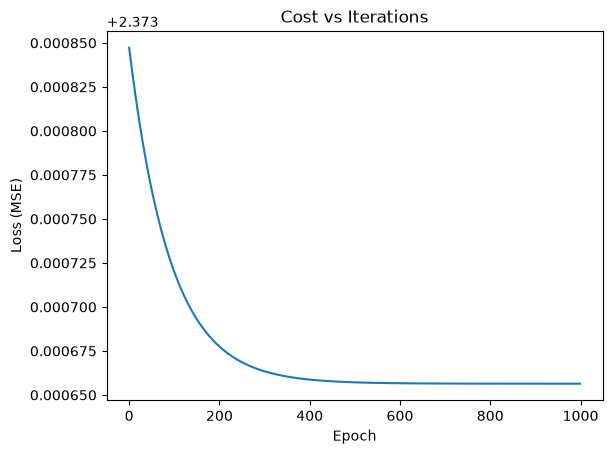

In [8]:
loss_history = []

for i in range(epochs):
    y_pred = w * X + b
    error = y_pred - y
    dw = (2/n) * np.sum(error * X)
    db = (2/n) * np.sum(error)
    w = w - lr_rate * dw
    b = b - lr_rate * db

    loss = np.mean(error**2)
    loss_history.append(loss)

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Cost vs Iterations")
plt.show()